In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [2]:
# Define data path
data_path = "../data/"

# Load Solar Irradiance
ssrd_tamale = pd.read_csv(data_path + "Solar Irradiance Tamale.csv")
ssrd_kumasi = pd.read_csv(data_path + "Solar Irradiance Kumasi.csv")
ssrd_axim = pd.read_csv(data_path + "Solar Irradiance Axim.csv")

# Load Precipitation
precip_tamale = pd.read_csv(data_path + "Precipitation Tamale.csv")
precip_kumasi = pd.read_csv(data_path + "Precipitation Kumasi.csv")
precip_axim = pd.read_csv(data_path + "Precipitation Axim.csv")

# Load Temperature
temp_tamale = pd.read_csv(data_path + "2m temperature Tamale.csv")
temp_kumasi = pd.read_csv(data_path + "2m temperature Kumasi.csv")
temp_axim = pd.read_csv(data_path + "2m temperature Axim.csv")

# Load Nigeria demand data
nigeria = pd.read_excel(data_path + "Nigeria Load data.xlsx", header=3)

print("All files loaded successfully! ✅")
print(f"\nSample Tamale SSRD shape: {ssrd_tamale.shape}")
print(f"\nColumn names: {ssrd_tamale.columns.tolist()}")
print(f"\nFirst few rows:")
ssrd_tamale.head()

All files loaded successfully! ✅

Sample Tamale SSRD shape: (53472, 4)

Column names: ['valid_time', 'ssrd', 'latitude', 'longitude']

First few rows:


,valid_time,ssrd,latitude,longitude
0,2020-01-01 00:00:00,0.0,9.4,-0.8
1,2020-01-01 01:00:00,0.0,9.4,-0.8
2,2020-01-01 02:00:00,0.0,9.4,-0.8
3,2020-01-01 03:00:00,0.0,9.4,-0.8
4,2020-01-01 04:00:00,0.0,9.4,-0.8


In [3]:
print("Nigeria Load Data Shape:", nigeria.shape)
print("\nColumn names:", nigeria.columns.tolist())
print("\nFirst few rows:")
nigeria.head()

Nigeria Load Data Shape: (8784, 5)

Column names: ['date time', 'Year', 'Quarter', 'National Unsuppressed Demand', 'National Suppressed Demand']

First few rows:


,date time,Year,Quarter,National Unsuppressed Demand,National Suppressed Demand
0,2016-01-01 00:00:00,2016,Q1,4670.268405,2527.804878
1,2016-01-01 01:00:00,2016,Q1,4665.287441,2789.024390
2,2016-01-01 02:00:00,2016,Q1,4682.517299,2815.121951
3,2016-01-01 03:00:00,2016,Q1,4703.791990,2785.121951
4,2016-01-01 04:00:00,2016,Q1,4857.064195,2794.878049


In [4]:
# ── 1. Parse timestamps ──────────────────────────────────────────
for df in [ssrd_tamale, ssrd_kumasi, ssrd_axim,
           precip_tamale, precip_kumasi, precip_axim,
           temp_tamale, temp_kumasi, temp_axim]:
    df['valid_time'] = pd.to_datetime(df['valid_time'])

nigeria['date time'] = pd.to_datetime(nigeria['date time'])

# ── 2. Keep only needed columns ──────────────────────────────────
nigeria_clean = nigeria[['date time', 'National Suppressed Demand']].copy()
nigeria_clean.columns = ['datetime', 'demand_mw']

# ── 3. Scale Nigeria demand down to mini-grid level (50kW peak) ──
max_demand = nigeria_clean['demand_mw'].max()
nigeria_clean['load_kw'] = (nigeria_clean['demand_mw'] / max_demand) * 50
nigeria_clean = nigeria_clean.drop(columns=['demand_mw'])

# ── 4. Cycle Nigeria 2016 data to cover 2020–2026 ────────────────
era5_start = pd.Timestamp('2020-01-01')
era5_end   = pd.Timestamp('2026-02-05 23:00:00')
hourly_index = pd.date_range(start=era5_start, end=era5_end, freq='h')

# Tile the 8784-row pattern across the full date range
n_repeats = int(np.ceil(len(hourly_index) / len(nigeria_clean)))
load_repeated = pd.DataFrame({
    'datetime': hourly_index,
    'load_kw': np.tile(nigeria_clean['load_kw'].values, n_repeats)[:len(hourly_index)]
})

print("✅ Load data prepared!")
print(f"Load date range: {load_repeated['datetime'].min()} → {load_repeated['datetime'].max()}")
print(f"Load shape: {load_repeated.shape}")
print(f"Peak load: {load_repeated['load_kw'].max():.2f} kW")
print(f"Min load:  {load_repeated['load_kw'].min():.2f} kW")
load_repeated.head()

✅ Load data prepared!
Load date range: 2020-01-01 00:00:00 → 2026-02-05 23:00:00
Load shape: (53472, 2)
Peak load: 50.00 kW
Min load:  7.80 kW


,datetime,load_kw
0,2020-01-01 00:00:00,32.527776
1,2020-01-01 01:00:00,35.889147
2,2020-01-01 02:00:00,36.224970
3,2020-01-01 03:00:00,35.838930
4,2020-01-01 04:00:00,35.964472


In [5]:
def merge_location(ssrd, precip, temp, location_name):
    # Rename columns
    ssrd_df   = ssrd[['valid_time', 'ssrd']].rename(columns={'valid_time': 'datetime'})
    precip_df = precip[['valid_time', 'tp']].rename(columns={'valid_time': 'datetime'})
    temp_df   = temp[['valid_time', 't2m']].rename(columns={'valid_time': 'datetime'})

    # Merge ERA5 variables
    df = ssrd_df.merge(precip_df, on='datetime')
    df = df.merge(temp_df, on='datetime')

    # Merge load data
    df = df.merge(load_repeated, on='datetime')

    # Convert SSRD from J/m² to W/m²
    df['ssrd_wm2'] = df['ssrd'] / 3600
    df = df.drop(columns=['ssrd'])

    # Convert temperature from Kelvin to Celsius
    df['temp_c'] = df['t2m'] - 273.15
    df = df.drop(columns=['t2m'])

    # Add location label
    df['location'] = location_name

    print(f"✅ {location_name}: {df.shape} | Columns: {df.columns.tolist()}")
    return df

# Merge all 3 locations
tamale_df = merge_location(ssrd_tamale, precip_tamale, temp_tamale, 'Tamale')
kumasi_df = merge_location(ssrd_kumasi, precip_kumasi, temp_kumasi, 'Kumasi')
axim_df   = merge_location(ssrd_axim,   precip_axim,   temp_axim,   'Axim')

print("\nSample Tamale data:")
tamale_df.head()

✅ Tamale: (53472, 6) | Columns: ['datetime', 'tp', 'load_kw', 'ssrd_wm2', 'temp_c', 'location']
✅ Kumasi: (53472, 6) | Columns: ['datetime', 'tp', 'load_kw', 'ssrd_wm2', 'temp_c', 'location']
✅ Axim: (53472, 6) | Columns: ['datetime', 'tp', 'load_kw', 'ssrd_wm2', 'temp_c', 'location']

Sample Tamale data:


,datetime,tp,load_kw,ssrd_wm2,temp_c,location
0,2020-01-01 00:00:00,0.0,32.527776,0.0,23.64807,Tamale
1,2020-01-01 01:00:00,0.0,35.889147,0.0,22.98400,Tamale
2,2020-01-01 02:00:00,0.0,36.224970,0.0,22.38000,Tamale
3,2020-01-01 03:00:00,0.0,35.838930,0.0,21.79302,Tamale
4,2020-01-01 04:00:00,0.0,35.964472,0.0,21.26590,Tamale


In [6]:
# Combine all 3 locations into one master dataset
master_df = pd.concat([tamale_df, kumasi_df, axim_df], ignore_index=True)

# Reorder columns neatly
master_df = master_df[['datetime', 'location', 'ssrd_wm2', 'tp', 'temp_c', 'load_kw']]

# Check for missing values
print("✅ Master dataset created!")
print(f"Total shape: {master_df.shape}")
print(f"\nMissing values:\n{master_df.isnull().sum()}")
print(f"\nLocations: {master_df['location'].unique()}")
print(f"\nDate range: {master_df['datetime'].min()} → {master_df['datetime'].max()}")
print(f"\nSample data:")
master_df.head(10)

✅ Master dataset created!
Total shape: (160416, 6)

Missing values:
datetime    0
location    0
ssrd_wm2    0
tp          0
temp_c      0
load_kw     0
dtype: int64

Locations: ['Tamale' 'Kumasi' 'Axim']

Date range: 2020-01-01 00:00:00 → 2026-02-05 23:00:00

Sample data:


,datetime,location,ssrd_wm2,tp,temp_c,load_kw
0,2020-01-01 00:00:00,Tamale,0.000000,0.0,23.64807,32.527776
1,2020-01-01 01:00:00,Tamale,0.000000,0.0,22.98400,35.889147
2,2020-01-01 02:00:00,Tamale,0.000000,0.0,22.38000,36.224970
3,2020-01-01 03:00:00,Tamale,0.000000,0.0,21.79302,35.838930
4,2020-01-01 04:00:00,Tamale,0.000000,0.0,21.26590,35.964472
5,2020-01-01 05:00:00,Tamale,0.000000,0.0,20.75680,36.946833
6,2020-01-01 06:00:00,Tamale,0.000000,0.0,20.27730,36.918586
7,2020-01-01 07:00:00,Tamale,23.967222,0.0,19.81680,37.995104
8,2020-01-01 08:00:00,Tamale,195.298333,0.0,22.20580,35.518800
9,2020-01-01 09:00:00,Tamale,422.457778,0.0,25.27816,30.773335


In [7]:
# Check column names of each file
print("SSRD Columns:")
print("Tamale:", ssrd_tamale.columns.tolist())
print("Kumasi:", ssrd_kumasi.columns.tolist())
print("Axim:  ", ssrd_axim.columns.tolist())

print("\nPrecip Columns:")
print("Tamale:", precip_tamale.columns.tolist())
print("Kumasi:", precip_kumasi.columns.tolist())
print("Axim:  ", precip_axim.columns.tolist())

print("\nTemp Columns:")
print("Tamale:", temp_tamale.columns.tolist())
print("Kumasi:", temp_kumasi.columns.tolist())
print("Axim:  ", temp_axim.columns.tolist())

SSRD Columns:
Tamale: ['valid_time', 'ssrd', 'latitude', 'longitude']
Kumasi: ['valid_time', 'ssrd', 'latitude', 'longitude']
Axim:   ['valid_time', 'ssrd', 'latitude', 'longitude']

Precip Columns:
Tamale: ['valid_time', 'tp', 'latitude', 'longitude']
Kumasi: ['valid_time', 'tp', 'latitude', 'longitude']
Axim:   ['valid_time', 'tp', 'latitude', 'longitude']

Temp Columns:
Tamale: ['valid_time', 't2m', 'latitude', 'longitude']
Kumasi: ['valid_time', 't2m', 'latitude', 'longitude']
Axim:   ['valid_time', 't2m', 'latitude', 'longitude']


In [8]:
# Check timestamp formats across all files
print("SSRD Timestamps:")
print("Tamale first:", ssrd_tamale['valid_time'].iloc[0], "| last:", ssrd_tamale['valid_time'].iloc[-1])
print("Kumasi first:", ssrd_kumasi['valid_time'].iloc[0], "| last:", ssrd_kumasi['valid_time'].iloc[-1])
print("Axim   first:", ssrd_axim['valid_time'].iloc[0],   "| last:", ssrd_axim['valid_time'].iloc[-1])

print("\nPrecip Timestamps:")
print("Tamale first:", precip_tamale['valid_time'].iloc[0], "| last:", precip_tamale['valid_time'].iloc[-1])
print("Kumasi first:", precip_kumasi['valid_time'].iloc[0], "| last:", precip_kumasi['valid_time'].iloc[-1])
print("Axim   first:", precip_axim['valid_time'].iloc[0],   "| last:", precip_axim['valid_time'].iloc[-1])

print("\nTemp Timestamps:")
print("Tamale first:", temp_tamale['valid_time'].iloc[0], "| last:", temp_tamale['valid_time'].iloc[-1])
print("Kumasi first:", temp_kumasi['valid_time'].iloc[0], "| last:", temp_kumasi['valid_time'].iloc[-1])
print("Axim   first:", temp_axim['valid_time'].iloc[0],   "| last:", temp_axim['valid_time'].iloc[-1])

SSRD Timestamps:
Tamale first: 2020-01-01 00:00:00 | last: 2026-02-05 23:00:00
Kumasi first: 2020-01-01 00:00:00 | last: 2026-02-05 23:00:00
Axim   first: 2020-01-01 00:00:00 | last: 2026-02-05 23:00:00

Precip Timestamps:
Tamale first: 2020-01-01 00:00:00 | last: 2026-02-05 23:00:00
Kumasi first: 2020-01-01 00:00:00 | last: 2026-02-05 23:00:00
Axim   first: 2020-01-01 00:00:00 | last: 2026-02-05 23:00:00

Temp Timestamps:
Tamale first: 2020-01-01 00:00:00 | last: 2026-02-05 23:00:00
Kumasi first: 2020-01-01 00:00:00 | last: 2026-02-05 23:00:00
Axim   first: 2020-01-01 00:00:00 | last: 2026-02-05 23:00:00


In [12]:
# Strip timezone info from all ERA5 files
for df in [ssrd_tamale, ssrd_kumasi, ssrd_axim,
           precip_tamale, precip_kumasi, precip_axim,
           temp_tamale, temp_kumasi, temp_axim]:
    df['valid_time'] = pd.to_datetime(df['valid_time']).dt.tz_localize(None)

# Also strip from load data
load_repeated['datetime'] = pd.to_datetime(load_repeated['datetime']).dt.tz_localize(None)

# Re-merge all locations
tamale_df = merge_location(ssrd_tamale, precip_tamale, temp_tamale, 'Tamale')
kumasi_df = merge_location(ssrd_kumasi, precip_kumasi, temp_kumasi, 'Kumasi')
axim_df   = merge_location(ssrd_axim,   precip_axim,   temp_axim,   'Axim')

# Rebuild master dataset
master_df = pd.concat([tamale_df, kumasi_df, axim_df], ignore_index=True)
master_df = master_df[['datetime', 'location', 'ssrd_wm2', 'tp', 'temp_c', 'load_kw']]

print("✅ Master dataset rebuilt!")
print(f"Total shape: {master_df.shape}")
print(f"\nMissing values:\n{master_df.isnull().sum()}")

✅ Tamale: (53472, 6) | Columns: ['datetime', 'tp', 'load_kw', 'ssrd_wm2', 'temp_c', 'location']
✅ Kumasi: (53472, 6) | Columns: ['datetime', 'tp', 'load_kw', 'ssrd_wm2', 'temp_c', 'location']
✅ Axim: (53472, 6) | Columns: ['datetime', 'tp', 'load_kw', 'ssrd_wm2', 'temp_c', 'location']
✅ Master dataset rebuilt!
Total shape: (160416, 6)

Missing values:
datetime    0
location    0
ssrd_wm2    0
tp          0
temp_c      0
load_kw     0
dtype: int64


In [10]:
# Check missing values per location
for loc, df in [('Tamale', tamale_df), ('Kumasi', kumasi_df), ('Axim', axim_df)]:
    print(f"\n{loc} missing values:")
    print(df.isnull().sum())

# Check if timestamps actually match between ssrd and load for Tamale
print("\nTamale SSRD datetime sample:")
print(ssrd_tamale['valid_time'].head())

print("\nLoad repeated datetime sample:")
print(load_repeated['datetime'].head())

print("\nTamale SSRD dtype:", ssrd_tamale['valid_time'].dtype)
print("Load datetime dtype:", load_repeated['datetime'].dtype)


Tamale missing values:
datetime    0
tp          0
load_kw     0
ssrd_wm2    0
temp_c      0
location    0
dtype: int64

Kumasi missing values:
datetime    0
tp          0
load_kw     0
ssrd_wm2    0
temp_c      0
location    0
dtype: int64

Axim missing values:
datetime    0
tp          0
load_kw     0
ssrd_wm2    0
temp_c      0
location    0
dtype: int64

Tamale SSRD datetime sample:
0   2020-01-01 00:00:00
1   2020-01-01 01:00:00
2   2020-01-01 02:00:00
3   2020-01-01 03:00:00
4   2020-01-01 04:00:00
Name: valid_time, dtype: datetime64[ns]

Load repeated datetime sample:
0   2020-01-01 00:00:00
1   2020-01-01 01:00:00
2   2020-01-01 02:00:00
3   2020-01-01 03:00:00
4   2020-01-01 04:00:00
Name: datetime, dtype: datetime64[ns]

Tamale SSRD dtype: datetime64[ns]
Load datetime dtype: datetime64[ns]


In [11]:
# Check Axim files individually
print("SSRD Axim sample:")
print(ssrd_axim.head())

print("\nPrecip Axim sample:")
print(precip_axim.head())

print("\nTemp Axim sample:")
print(temp_axim.head())

print("\nSSRD Axim valid_time dtype:", ssrd_axim['valid_time'].dtype)
print("Precip Axim valid_time dtype:", precip_axim['valid_time'].dtype)
print("Temp Axim valid_time dtype:", temp_axim['valid_time'].dtype)

# Check if any NaN already exist in raw Axim files
print("\nRaw Axim SSRD nulls:", ssrd_axim.isnull().sum().to_dict())
print("Raw Axim Precip nulls:", precip_axim.isnull().sum().to_dict())
print("Raw Axim Temp nulls:", temp_axim.isnull().sum().to_dict())

SSRD Axim sample:
           valid_time  ssrd  latitude  longitude
0 2020-01-01 00:00:00   0.0       4.9       -2.2
1 2020-01-01 01:00:00   0.0       4.9       -2.2
2 2020-01-01 02:00:00   0.0       4.9       -2.2
3 2020-01-01 03:00:00   0.0       4.9       -2.2
4 2020-01-01 04:00:00   0.0       4.9       -2.2

Precip Axim sample:
           valid_time        tp  latitude  longitude
0 2020-01-01 00:00:00  0.000078       4.9       -2.2
1 2020-01-01 01:00:00  0.000134       4.9       -2.2
2 2020-01-01 02:00:00  0.000182       4.9       -2.2
3 2020-01-01 03:00:00  0.000292       4.9       -2.2
4 2020-01-01 04:00:00  0.000002       4.9       -2.2

Temp Axim sample:
           valid_time        t2m  latitude  longitude
0 2020-01-01 00:00:00  299.95430       4.9       -2.2
1 2020-01-01 01:00:00  299.92892       4.9       -2.2
2 2020-01-01 02:00:00  299.78195       4.9       -2.2
3 2020-01-01 03:00:00  299.64224       4.9       -2.2
4 2020-01-01 04:00:00  299.11120       4.9       -2.2

SSRD 

✅ Master dataset saved!


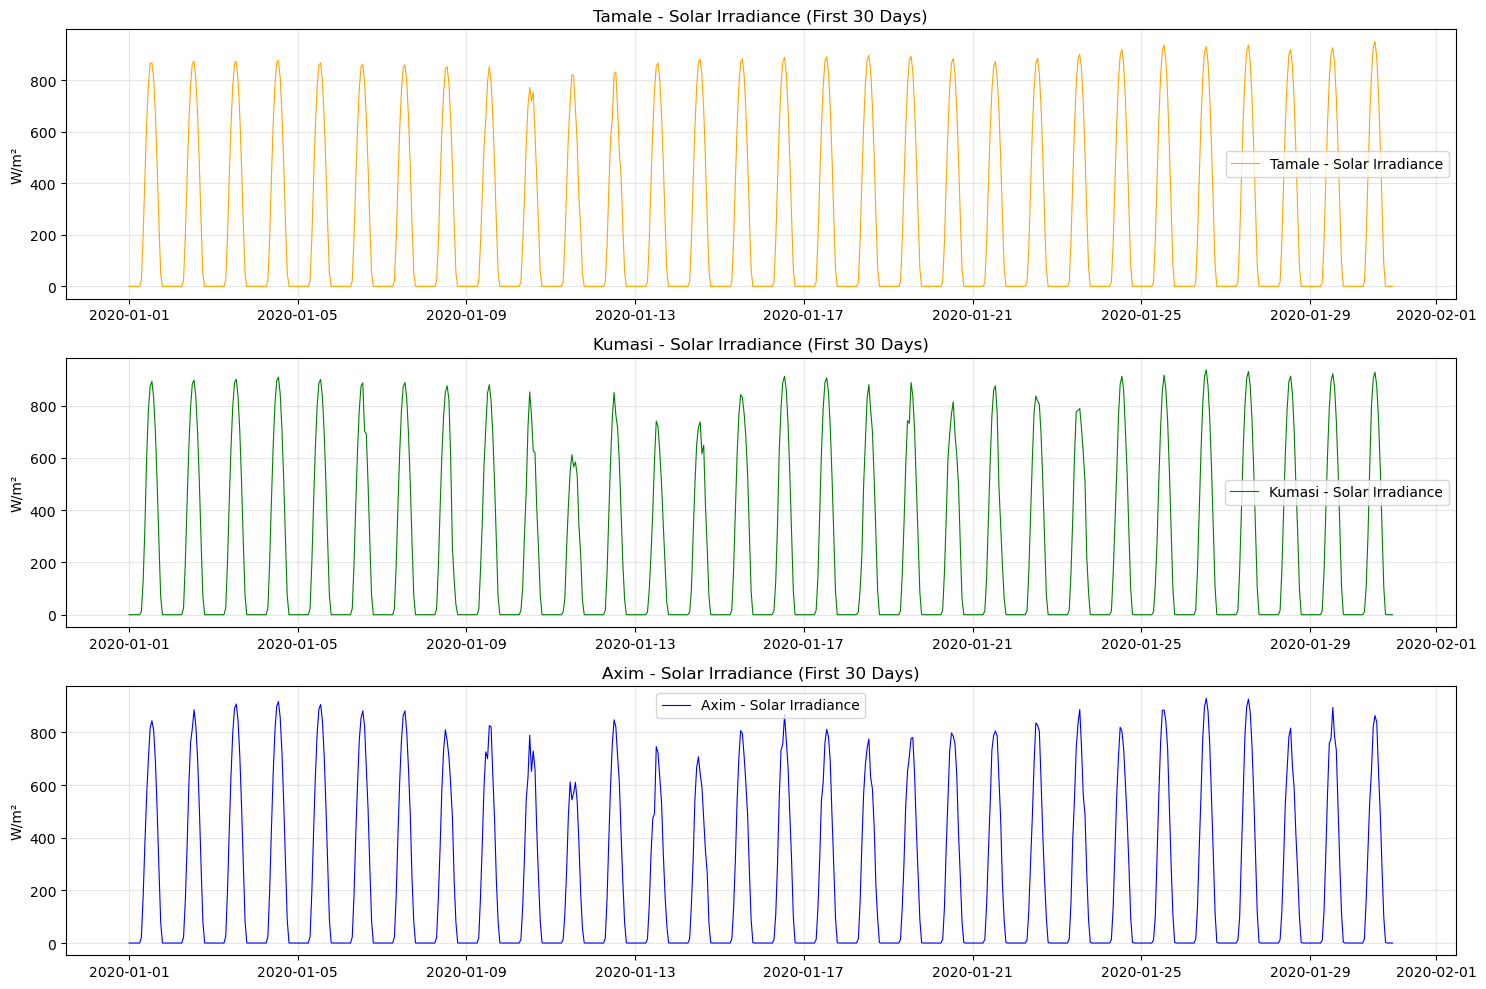

✅ Plot saved!


In [13]:
# Save master dataset to data folder
master_df.to_csv('../data/master_dataset.csv', index=False)
print("✅ Master dataset saved!")

# Plot a quick overview of all 3 locations
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for i, (loc, color) in enumerate(zip(['Tamale', 'Kumasi', 'Axim'], 
                                       ['orange', 'green', 'blue'])):
    loc_df = master_df[master_df['location'] == loc].head(24*30)  # first 30 days
    axes[i].plot(loc_df['datetime'], loc_df['ssrd_wm2'], 
                 color=color, linewidth=0.8, label=f'{loc} - Solar Irradiance')
    axes[i].set_title(f'{loc} - Solar Irradiance (First 30 Days)', fontsize=12)
    axes[i].set_ylabel('W/m²')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/solar_overview.png', dpi=150)
plt.show()
print("✅ Plot saved!")